In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ── make nmc_utils importable as `nmc` ───────────────────────────────────────
NOTEBOOK_DIR = Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
import nmc_utils as nmc

nmc.set_paper_style()
print("nmc_utils loaded")

nmc_utils loaded


In [15]:
# ── paths ─────────────────────────────────────────────────────────────────────
# Default: relative path from NMC-samples/ to the build folder.
# Override with an absolute Path if your build lives elsewhere:
#   EXE_DIR = Path("/Users/you/wherever/NMC/Build/Products/Debug")
EXE_DIR  = (NOTEBOOK_DIR / "../NMC/Build/Products/Debug").resolve()
EXE_NAME = "nmc"
EXE_PATH = EXE_DIR / EXE_NAME

# ── simulation parameters ─────────────────────────────────────────────────────
PARAMS = dict(
    fname                  = "example",
    width                  = 5,      # mm   — simulation volume half-width
    Nx                     = 100,
    Ny                     = 100,
    Nz                     = 100,
    raman_prob             = 0.05,
    stim_raman_prob        = 0.1,
    interaction_distance   = 0.01,     # mm
    step_size              = 0.001,    # mm
    laser_beam_radius      = 0.05,     # mm
    laser_beam_pulse_width = 5.0,      # ps
    laser_beam_pulse_delay = 15.0,     # ps
    cutoff_radius          = 3.0,      # mm
    zfocus                 = 1.0,      # mm  focal depth
    numerial_aperture      = 1.0,      # n_exit · sin(θ_max)
    det_state              = 1,        # 0 = reflectance, 1 = transmittance
    Nt                     = 1,
    mua                    = 0.01,      # mm⁻¹
    mus                    = 100.0,     # mm⁻¹
    g                      = 0.6,
    index_of_refraction    = 1.6,
    mua_r                  = 0.01,      # mm⁻¹
    mus_r                  = 100.0,     # mm⁻¹
    g_r                    = 0.6,
)

print(f"EXE  : {EXE_PATH}")

EXE  : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug/nmc


In [17]:
### RUN ###

# human-readable config → notebook folder
# machine-readable .mci → build folder (next to the exe)
mci_path, cfg_path = nmc.init_config_file(
    cfg_dir=NOTEBOOK_DIR,
    mci_dir=EXE_DIR,
    **PARAMS,
)
print(f"CFG written : {cfg_path}")
print(f"MCI written : {mci_path}")

nmc.run(
        exe_path=EXE_PATH,
        mci_name=PARAMS["fname"],
        workdir=EXE_DIR,
    )

CFG written : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC-samples/config file example.txt
MCI written : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug/example_H.mci
[nmc] Command : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug/nmc example
[nmc] cwd     : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug
[nmc] ── simulation output ──────────────────
[nmc] ─────────────────────────────────────
[nmc] stderr:
2026-04-03 10:05:47.168 nmc[3556:46886] Reading file example_H.mci
2026-04-03 10:05:47.169 nmc[3556:46886] Hello, let's do Raman!
2026-04-03 10:05:47.169 nmc[3556:46886] 
GEOMETRY:
2026-04-03 10:05:47.169 nmc[3556:46886] width = 5.00 mm
2026-04-03 10:05:47.169 nmc[3556:46886] Nx = 100, Ny = 100, Nz = 100
2026-04-03 10:05:47.169 nmc[3556:46886] 
RUN:
2026-04-03 10:05:47.169 nmc[3556:46886] step size = 0.0010 [mm]
2026-04-03 10:05:47.169 nmc[3556:46886] detection state = 1
2026-04-03 10:05:47.169 nmc[3556:46886] 
MEDIUM

In [3]:
d = 1000             # particle diameter [nm]
lambda0 = 1064      # wavelength in vacuum [nm]
n_medium = 1.48     # refractive index of DMSO
n_particle = 2.2    # refractive index of CeO2
m_particle = n_particle - 0.0001j
f_v = 0.0114

solution = nmc.compute_mie_medium_params(d,lambda0,668,f_v,n_medium,m_particle)

PARAMS.update(
    mua   = solution['mua'],
    mus   = solution['mus'],
    g     = solution['g'],
    mua_r = solution['mua_r'],     
    mus_r = solution['mus_r'],               
    g_r   = solution['g_r'],       
)

print(PARAMS)

{'fname': 'example', 'width': 0.5, 'Nx': 100, 'Ny': 100, 'Nz': 100, 'raman_prob': 0.05, 'stim_raman_prob': 0.1, 'interaction_distance': 0.01, 'step_size': 0.001, 'laser_beam_radius': 0.05, 'laser_beam_pulse_width': 5.0, 'laser_beam_pulse_delay': 15.0, 'cutoff_radius': 3.0, 'zfocus': 1.0, 'numerial_aperture': 1.0, 'det_state': 0, 'Nt': 1, 'mua': 0.036801516055344534, 'mus': 48.607857628535086, 'g': 0.6264694067374256, 'index_of_refraction': 1.6, 'mua_r': 0.06442338917281275, 'mus_r': 53.32876587755813, 'g_r': 0.628298574743429}


In [5]:
### TRAJECTORIES ###

photons_csv = EXE_DIR / expected_output

df_raw, df_summary = nmc.load_photons(
    photons_csv,
    z_bottom=PARAMS["width"],
    types_of_interest=tuple(TYPES_PLOT),
)

# attach readable label columns
df_raw["type_label"]     = df_raw["type"].map(nmc.TYPE_LABELS)
df_summary["type_label"] = df_summary["prev_type"].map(nmc.TYPE_LABELS)

print(f"\ndf_raw    : {df_raw.shape}")
print(f"df_summary: {df_summary.shape}")

[load_photons] Total rows       : 10,879,252
[load_photons] Unique markers   : 100,000
[load_photons] Summarised       : 100,000  (after type filter: [1, 2])

[load_photons] Exit state counts (post-filter):
bottom      42551
top         40838
absorbed    16611

[load_photons] prev_type counts (post-filter):
1    94587
2     5413

df_raw    : (10879252, 8)
df_summary: (100000, 8)


SHOW_SRS auto-set to False  (max SRS RD = 0.0000)

RD arrays loaded:  laser (100, 100)  raman (100, 100)  srs (100, 100)


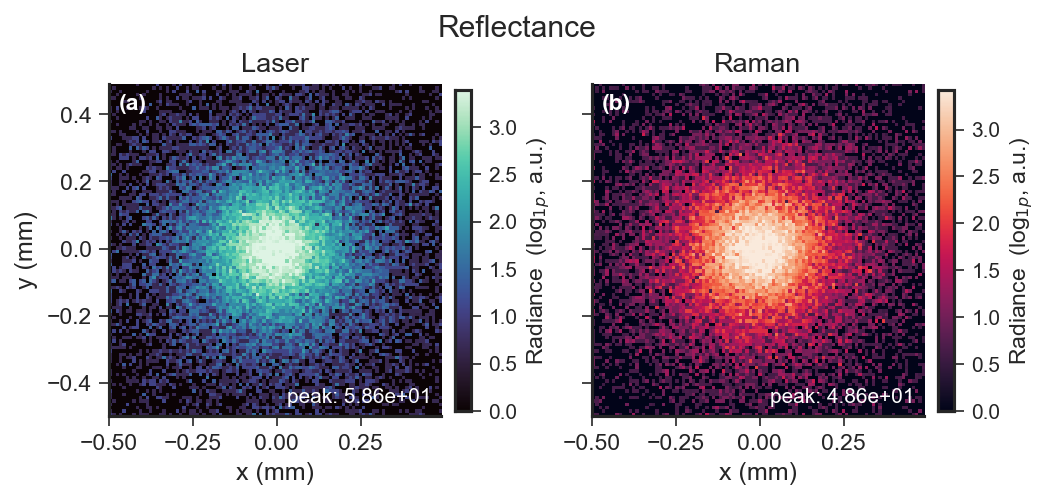

In [31]:
### RADIANCE ###

expected_rd  = f"rd_data_mus-{PARAMS['mus']:.2f}_NA-{PARAMS['numerial_aperture']:.2f}_zf-{PARAMS['zfocus']:.2f}.csv"

Nx    = int(PARAMS["Nx"])
Ny    = int(PARAMS["Ny"])
Nz    = int(PARAMS["Nz"])
width = PARAMS["width"]

rd = nmc.load_rd_data(
    EXE_DIR / expected_rd,
    Nx=Nx,
    Ny=Ny,
)

# build properly scaled xy coordinates
x, y = nmc.build_xy_coords(Nx, Ny, width)
dx   = x[1] - x[0]
dy   = y[1] - y[0]
extent_xy = [float(x.min()), float(x.max()), float(y.min()), float(y.max())]

# ── auto-detect SRS ───────────────────────────────────────────────────────────
srs_max = float(np.max(rd["srs"]))
SHOW_SRS = srs_max > 1.0
print(f"SHOW_SRS auto-set to {SHOW_SRS}  (max SRS RD = {srs_max:.4f})")
# override here if needed:  SHOW_SRS = True

print(f"\nRD arrays loaded:  laser {rd['laser'].shape}  "
      f"raman {rd['raman'].shape}  srs {rd['srs'].shape}")

USE_LOG1P = True          # True: log scale; False: linear

_CHANNEL_SPEC = [
    (rd["laser"], "Laser", "mako"),
    (rd["raman"], "Raman", "rocket"),
]
if SHOW_SRS:
    _CHANNEL_SPEC.append((rd["srs"], "SRS", "viridis"))

n_panels = len(_CHANNEL_SPEC)

# figure sizing (Nature double-column) 
_FIG_SIZES = {2: (7.0, 3.2), 3: (7.0, 2.8)}
figsize = _FIG_SIZES.get(n_panels, (3.5 * n_panels, 3.0))

fig, axes = plt.subplots(
    1, n_panels,
    figsize=figsize,
    sharey=True,
)
if n_panels == 1:
    axes = [axes]

_PANEL_LABELS = ["(a)", "(b)", "(c)"]
_CBAR_LABEL   = "Radiance  (log$_{1p}$, a.u.)" if USE_LOG1P else "Radiance  (a.u.)"

for idx, (ax, (arr, title, cmap)) in enumerate(zip(axes, _CHANNEL_SPEC)):
    # per-channel colour limits (robust percentile) 
    vmin, vmax = nmc.robust_clim(arr, p_low=1, p_high=99)

    data = np.log1p(np.maximum(arr, 0.0)) if USE_LOG1P else arr

    im = ax.imshow(
        data.T,                     # rows=y, cols=x 
        origin="lower",
        extent=extent_xy,
        aspect="equal",
        cmap=cmap,
        vmin=np.log1p(max(vmin, 0.0)) if USE_LOG1P else vmin,
        vmax=np.log1p(max(vmax, 0.0)) if USE_LOG1P else vmax,
    )

    # per-panel colourbar 
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(_CBAR_LABEL, fontsize=plt.rcParams["legend.fontsize"])
    cbar.ax.tick_params(labelsize=plt.rcParams["xtick.labelsize"] - 1)

    # peak-value annotation 
    peak_val = float(np.nanmax(arr))
    ax.text(
        0.97, 0.03,
        f"peak: {peak_val:.2e}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=plt.rcParams["legend.fontsize"] - 1,
        color="white",
    )

    # panel label (a) / (b) / (c)
    ax.text(
        0.03, 0.97,
        _PANEL_LABELS[idx],
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=plt.rcParams["legend.fontsize"],
        fontweight="bold",
        color="white",
    )

    ax.set_title(title)
    ax.set_xlabel("x (mm)")

axes[0].set_ylabel("y (mm)")

det_label = "Reflectance" if PARAMS["det_state"] == 0 else "Transmittance"
fig.suptitle(f"{det_label}")

sns.despine(fig=fig)

plt.show()

In [ ]:
### FLUENCE ###

# coordinate arrays
x_arr = np.linspace(-width, width, Nx)
z_arr = np.linspace(0,      width, Nz)

iy0 = int(Ny / 2)   # y = 0 voxel index

_FLUENCE_CMAPS = {1: "mako", 2: "rocket", 3: "viridis"}
_FIG_SIZES_FL  = {1: (3.5, 3.0), 2: (7.0, 3.2), 3: (7.0, 2.8)}
_PANEL_LABELS  = ["(a)", "(b)", "(c)"]
_CBAR_LABEL_FL = r"Fluence  (log$_{1p}$, a.u.)"

n_panels = len(FLUENCE_TYPES)
figsize  = _FIG_SIZES_FL.get(n_panels, (3.5 * n_panels, 3.2))

fig, axes = plt.subplots(1, n_panels, figsize=figsize, sharey=True)
if n_panels == 1:
    axes = [axes]

for idx, (ax, ptype) in enumerate(zip(axes, FLUENCE_TYPES)):
    sl     = fluence_vols[ptype][:, iy0, :]        # (Nx, Nz)
    log_sl = np.log1p(np.maximum(sl, 0.0))
    vmin_f, vmax_f = nmc.robust_clim(log_sl, p_low=1, p_high=99)

    im = ax.imshow(
        log_sl.T,
        origin="lower",
        extent=[float(x_arr.min()), float(x_arr.max()), 0.0, float(width)],
        aspect="auto",
        cmap=_FLUENCE_CMAPS.get(ptype, "mako"),
        vmin=vmin_f,
        vmax=vmax_f,
    )

    # per-panel colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(_CBAR_LABEL_FL, fontsize=plt.rcParams["legend.fontsize"])
    cbar.ax.tick_params(labelsize=plt.rcParams["xtick.labelsize"] - 1)

    # panel label
    ax.text(
        0.03, 0.97,
        _PANEL_LABELS[idx],
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=plt.rcParams["legend.fontsize"],
        fontweight="bold",
        color="white",
    )

    ax.set_title(nmc.TYPE_LABELS[ptype])
    ax.set_xlabel("x (mm)")

axes[0].set_ylabel("z (mm)")
axes[0].invert_yaxis()   # z = 0 (laser entry) at top; propagates to all sharey panels

fig.suptitle(f"Fluence: xz @ y = 0 ")

sns.despine(fig=fig)

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex5_fluence_static.pdf", bbox_inches="tight")
plt.show()